In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/filtered/Fil_SCF_20022.csv", index_col=0)

In [3]:
key_vars = ["RETQLIQ", "INCOME", "DEBT", "FINLIT", "AGE"]
df[key_vars].head()

,RETQLIQ,INCOME,DEBT,FINLIT,AGE
0,245000,38804.734469,195000,1,70
5,100000,224829.659320,518700,3,46
10,459000,445335.671340,17580000,3,68
15,1499000,152408.567130,0,3,74
20,0,56207.414830,11000,0,19


In [4]:
df[key_vars].describe()

,RETQLIQ,INCOME,DEBT,FINLIT,AGE
count,4.595000e+03,4.595000e+03,4.595000e+03,4595.000000,4595.000000
mean,5.972037e+05,1.593197e+06,3.653292e+05,2.303591,54.468988
std,3.177822e+06,1.233521e+07,2.630899e+06,0.829303,16.190491
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,18.000000
25%,0.000000e+00,4.215556e+04,0.000000e+00,2.000000,42.000000
50%,1.800000e+04,9.403933e+04,2.900000e+04,3.000000,56.000000
75%,3.500000e+05,2.648234e+05,2.162750e+05,3.000000,67.000000
max,1.492700e+08,4.532588e+08,1.238900e+08,3.000000,95.000000


<Axes: xlabel='INCOME', ylabel='Count'>

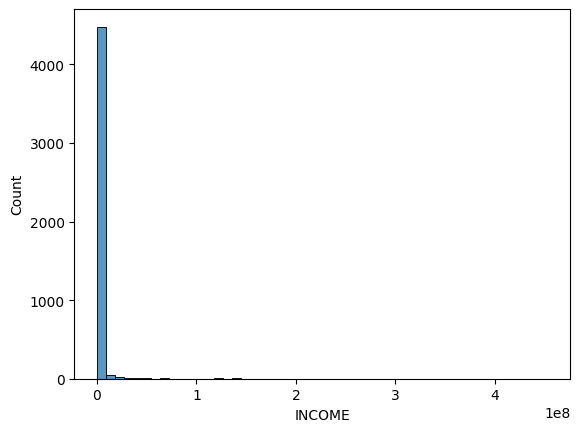

In [5]:
sns.histplot(df['INCOME'], bins=50)

<Axes: xlabel='RETQLIQ', ylabel='Count'>

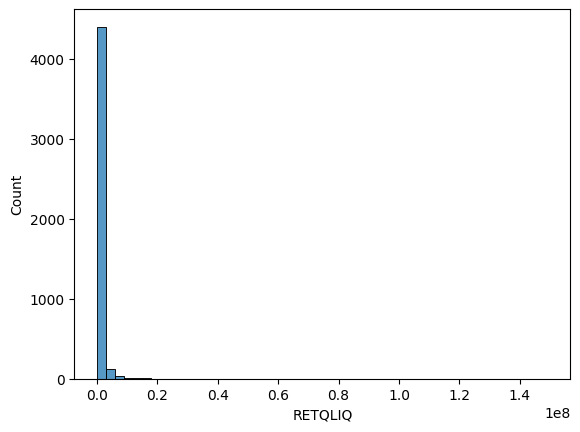

In [6]:
sns.histplot(df['RETQLIQ'], bins=50)

<Axes: xlabel='DEBT', ylabel='Count'>

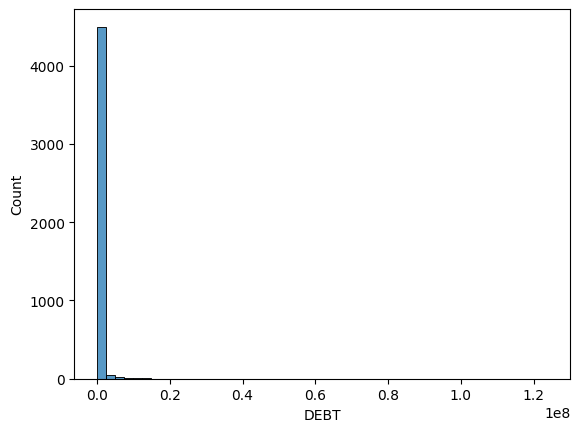

In [7]:
sns.histplot(df['DEBT'], bins=50)

<Axes: xlabel='FINLIT', ylabel='Count'>

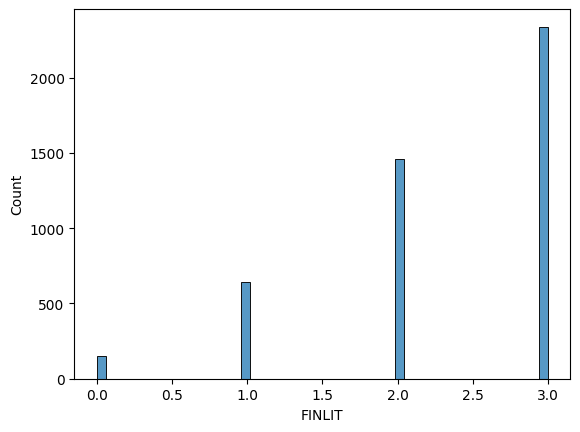

In [8]:
sns.histplot(df['FINLIT'], bins=50)

<Axes: xlabel='AGE', ylabel='Count'>

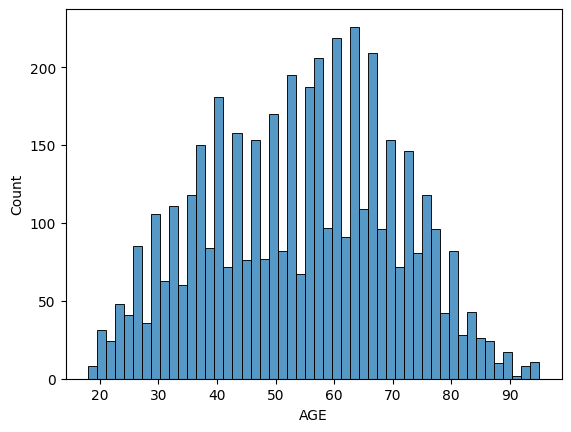

In [9]:
sns.histplot(df['AGE'], bins=50)

In [10]:
households_no_retirement = (df['RETQLIQ'] == 0).mean()
print(f"Households without retirement: {round(households_no_retirement, 3)*100}%")

Households without retirement: 40.8%


Text(0.5, 1.0, 'Retirement Savings Boxplot')

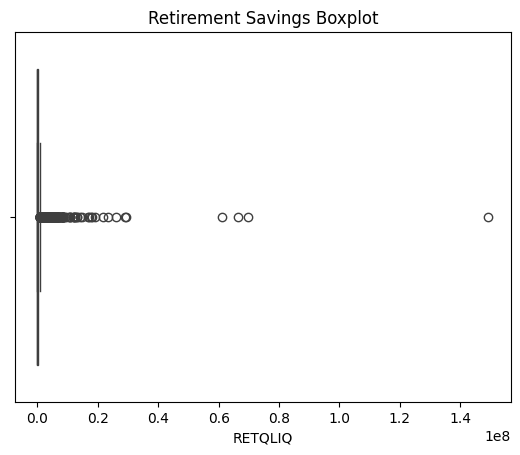

In [11]:
sns.boxplot(x="RETQLIQ", data=df)
plt.title("Retirement Savings Boxplot")

<Axes: xlabel='INCOME'>

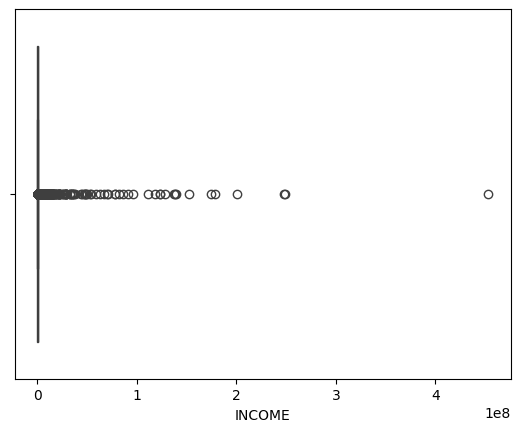

In [12]:
sns.boxplot(x="INCOME", data=df)

<Axes: xlabel='AGE'>

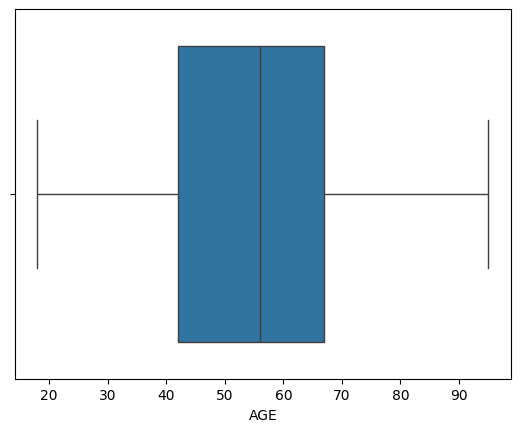

In [13]:
sns.boxplot(x="AGE", data=df)

In [14]:
df['LOG_INCOME'] = np.log1p(df['INCOME'])
df['LOG_DEBT'] = np.log1p(df['DEBT'])
df['LOG_RETQLIQ'] = np.log1p(df['RETQLIQ'])

<Axes: xlabel='LOG_INCOME'>

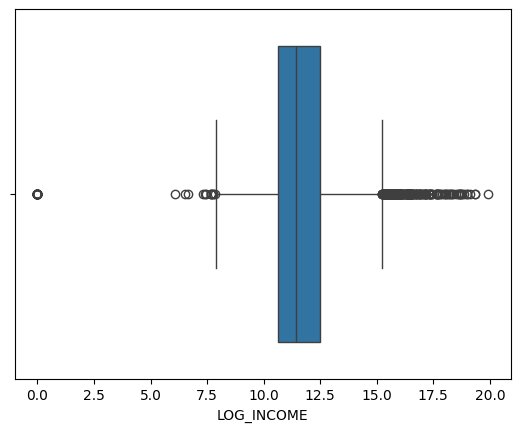

In [15]:
sns.boxplot(x="LOG_INCOME", data=df)

<Axes: xlabel='LOG_INCOME', ylabel='Count'>

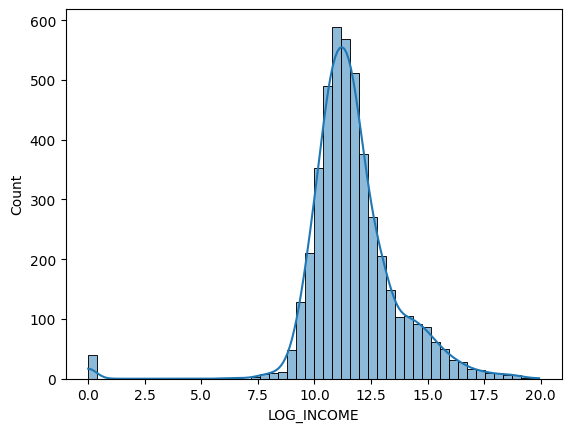

In [16]:
sns.histplot(df['LOG_INCOME'], bins=50, kde=True)

<Axes: xlabel='LOG_DEBT', ylabel='Count'>

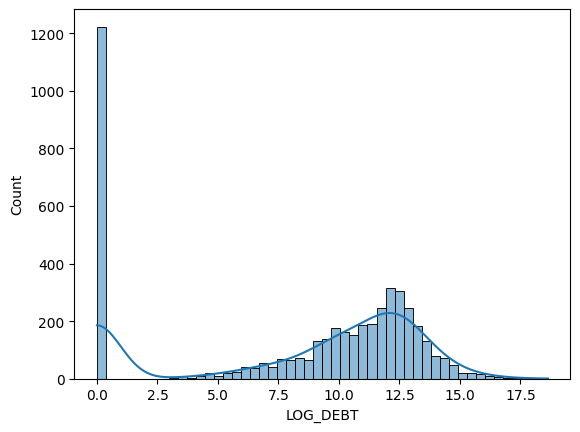

In [17]:
sns.histplot(df['LOG_DEBT'], bins=50, kde=True)

<Axes: xlabel='LOG_RETQLIQ', ylabel='Count'>

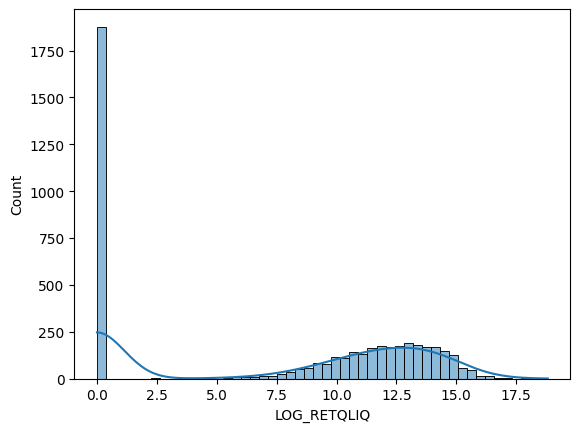

In [18]:
sns.histplot(df['LOG_RETQLIQ'], bins=50, kde=True)

In [19]:
df['HAS_DEBT'] = (df['DEBT'] > 0).astype(int)

Text(0.5, 1.0, 'Retirement Liquidity by Debt Status')

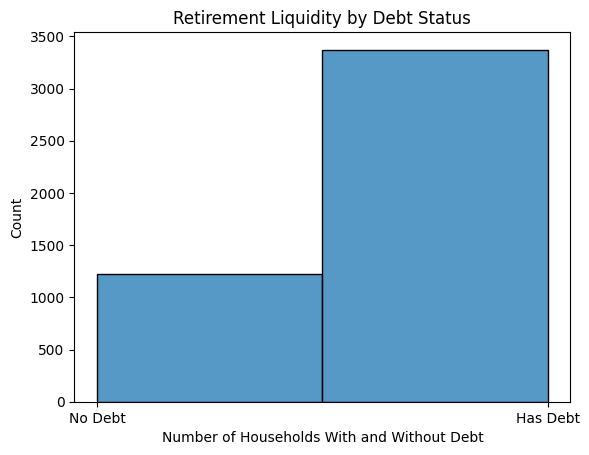

In [20]:
sns.histplot(df['HAS_DEBT'], bins=2)
plt.xticks([0,1], ['No Debt', 'Has Debt'])
plt.xlabel("Number of Households With and Without Debt")
plt.title('Retirement Liquidity by Debt Status')

<Axes: xlabel='HAS_DEBT'>

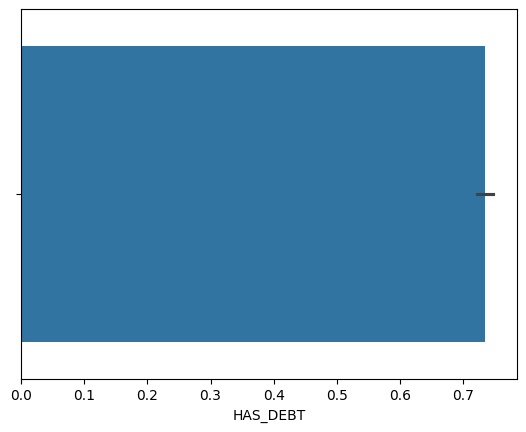

In [21]:
sns.barplot(x='HAS_DEBT', data=df)


<Axes: xlabel='HAS_DEBT', ylabel='RETQLIQ'>

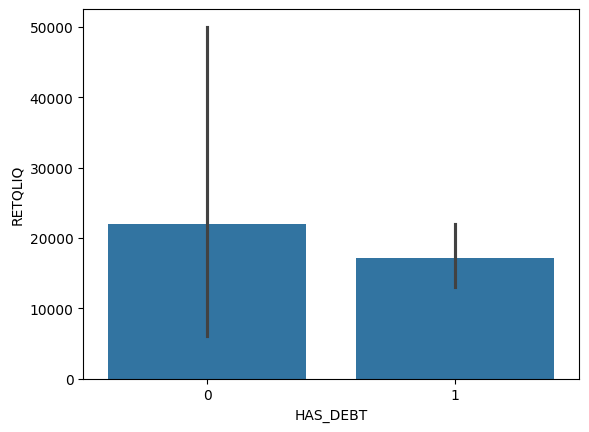

In [22]:
sns.barplot(x='HAS_DEBT', y='RETQLIQ', data=df, estimator='median')

<Axes: xlabel='LOG_RETQLIQ'>

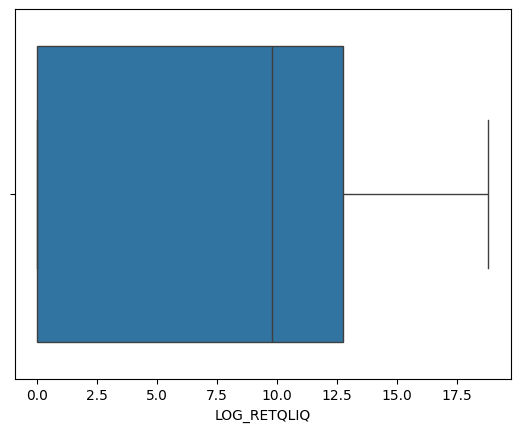

In [23]:
sns.boxplot(x='LOG_RETQLIQ', data=df)

In [24]:
df.columns

Index(['NETWORTH', 'INCOME', 'FIN', 'NFIN', 'DEBT', 'EQUITY', 'STOCKS',
       'HHOUSES', 'BUS', 'RETQLIQ', 'YESFINRISK', 'SPENDMOR', 'LATE',
       'EMERGSAV', 'LIQ', 'FINLIT', 'AGE', 'EDUC', 'MARRIED', 'KIDS', 'OCCAT1',
       'RET_ASSETS', 'LOG_INCOME', 'LOG_DEBT', 'LOG_RETQLIQ', 'HAS_DEBT'],
      dtype='str')

<Axes: xlabel='RETQLIQ'>

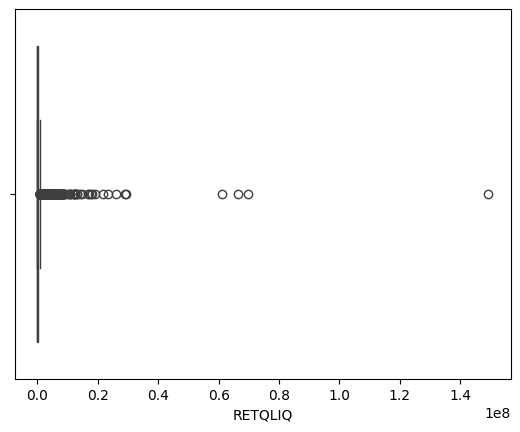

In [25]:
sns.boxplot(x="RETQLIQ", data=df)

In [26]:
zero_income_count = (df["INCOME"] == 0).sum()
zero_income_pct = zero_income_count / len(df) * 100

print(f"Zero income records: {zero_income_count}")
print(f"Percent of dataset: {zero_income_pct:.2f}%")

Zero income records: 39
Percent of dataset: 0.85%


In [27]:
pd.cut(
    df["INCOME"],
    bins=[-1, 0, 25000, 50000, 100000, 250000, 500000, 1000000, float("inf")],
    labels=[
        "0",
        "1-25k",
        "25k-50k",
        "50k-100k",
        "100k-250k",
        "250k-500k",
        "500k-1M",
        "1M+"
    ]
).value_counts().sort_index()

INCOME
0              39
1-25k         565
25k-50k       805
50k-100k      982
100k-250k    1016
250k-500k     409
500k-1M       224
1M+           555
Name: count, dtype: int64

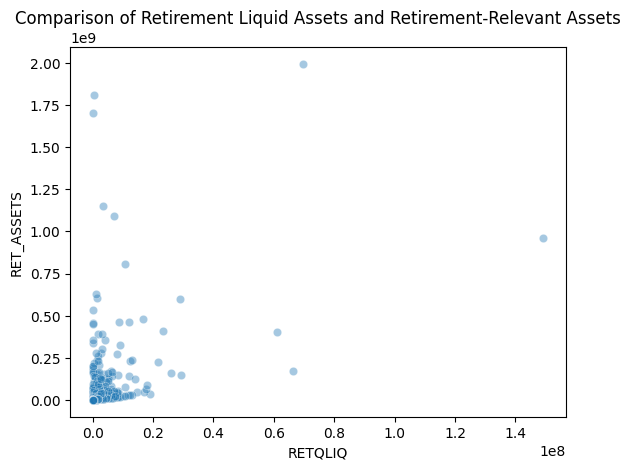

In [28]:
sns.scatterplot(data=df, x="RETQLIQ", y="RET_ASSETS", alpha=0.4)
plt.title("Comparison of Retirement Liquid Assets and Retirement-Relevant Assets")
plt.xlabel("RETQLIQ")
plt.ylabel("RET_ASSETS")
plt.show()

This scatterplot compares the original retirement liquid asset variable with the broader RET_ASSETS measure. Several households have relatively low RETQLIQ but substantially higher RET_ASSETS, suggesting that RETQLIQ alone may understate retirement-relevant financial resources. This supports the decision to use RET_ASSETS as the improved target basis.

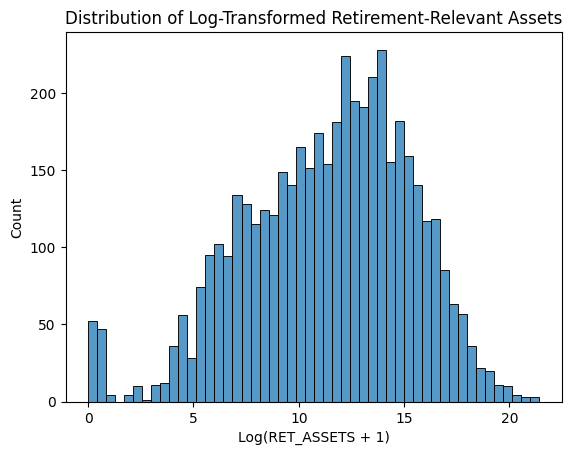

In [29]:
df["LOG_RET_ASSETS"] = np.log1p(df["RET_ASSETS"])

sns.histplot(df["LOG_RET_ASSETS"], bins=50)
plt.title("Distribution of Log-Transformed Retirement-Relevant Assets")
plt.xlabel("Log(RET_ASSETS + 1)")
plt.ylabel("Count")
plt.show()